In [1]:
from datetime import datetime
from pathlib import Path
import math
import sqlite3
import pickle

import yaml
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from get_collections_and_files import list_files_and_excluded_vars

In [2]:
# inspect db table
def inspect_table(db_path : Path, model: str, n: int = 1):
    table = model.lower()
    with sqlite3.connect(str(db_path)) as conn:
        cols = [r[1] for r in conn.execute(f"PRAGMA table_info({table})").fetchall()]
        count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        sample = conn.execute(f"SELECT * FROM {table} LIMIT ?", (n,)).fetchall()
    return {"table": table, "n_rows": count, "columns": cols, "sample_rows": sample}
db_path = "/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"

#inspect_table(db_path, "geosfp")

In [3]:
def load_quantiles_from_db(db_path: Path, model: str, year: int, month: int, id_string: str):
    table = model.lower()
    with sqlite3.connect(str(db_path)) as conn:
        row = conn.execute(
            f"SELECT quantiles, quantile_list FROM {table} "
            "WHERE model=? AND year=? AND month=? AND id_string=?",
            (model, year, month, id_string),
        ).fetchone()

    if row is None:
        print("Not Found")
        return None

    return pickle.loads(row[0]), pickle.loads(row[1])

1.8179149660291213e-11 1.792988719555577e-11


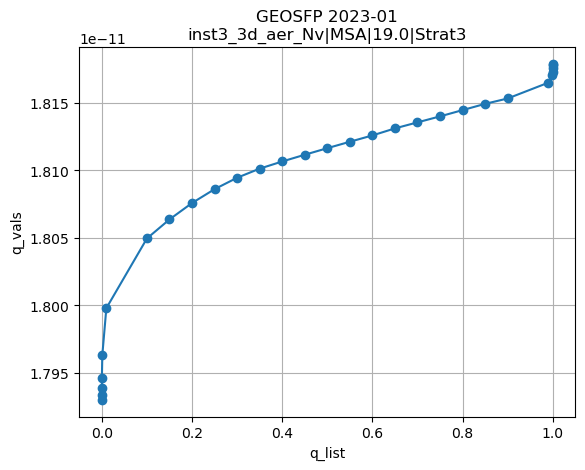

In [7]:
def plot_qcurve_from_db(db_path, model, year, month, id_key):
    ref = load_quantiles_from_db(db_path, model, year, month, id_key)

    if ref is None:
        return

    q_vals, q_list = ref

    q_vals = np.asarray(q_vals)
    q_list = np.asarray(q_list)
    
    print(max(q_vals), min(q_vals))

    plt.figure()
    plt.plot(q_list, q_vals, marker="o")
    plt.xlabel("q_list")
    plt.ylabel("q_vals")
    plt.title(f"{model} {year}-{month:02d}\n{id_key}")
    plt.grid(True)
    plt.show()


# Example:
plot_qcurve_from_db(
    db_path=Path("/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"),
    model="GEOSFP",   # IMPORTANT: must match table name in your SQL query - tablename is capitalized!
    year=2023,
    month=1,
    id_key="inst3_3d_aer_Nv|MSA|19.0|Strat3",
)

In [5]:
# visualization

LEV_NAMES = ["lev", "level", "pressure"]
LAT_NAMES = ["lat", "latitude", "y"]
LON_NAMES = ["lon", "longitude", "x"]
TIME_NAMES = ["time", "valid_time", "datetime"]

def load_strata(strata_file: str | Path):
    with open(strata_file, "r") as f:
        return yaml.safe_load(f)["STRATA"]

def pick_name(ds, names):
    return next((n for n in names if n in ds.coords), None)

def plot_id_key_slice(model: str, date: str, id_key: str, data_yaml_file: str, strata_file: str):
    # id_key = "collection|var|lev_val|stratum"
    coll, var, lev_str, sname = id_key.split("|", 3)
    lev_val = None if lev_str == "None" else lev_str

    dt = datetime.strptime(date, "%Y-%m-%d")
    _, collection_dict, excluded = list_files_and_excluded_vars(model=model, date=dt, data_yaml_file=data_yaml_file)
    strata = load_strata(strata_file)

    ds = xr.open_mfdataset(
        collection_dict[coll],
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    lat = pick_name(ds, LAT_NAMES)
    lon = pick_name(ds, LON_NAMES)
    lev = pick_name(ds, LEV_NAMES)
    time = pick_name(ds, TIME_NAMES)

    if lat is None or lon is None:
        raise ValueError("Could not identify latitude/longitude coordinate names.")
    if var not in ds:
        raise ValueError(f"Variable {var!r} not found in dataset.")

    da = ds[var]
    if lev_val is not None and lev is not None and lev in da.coords:
        da = da.sel({lev: lev_val})

    lat_min = strata[sname]["lat"]["min"]
    lat_max = strata[sname]["lat"]["max"]
    lat_vals = ds[lat].values
    da = da.sel({lat: slice(lat_min, lat_max) if np.all(np.diff(lat_vals) > 0) else slice(lat_max, lat_min)}).squeeze()

    dims_ok = {lat, lon}
    if time in da.dims:
        dims_ok.add(time)
        da = da.transpose(time, lat, lon)
        n = da.sizes[time]
        ncols = min(3, n)
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False, constrained_layout=True)

        vmin = float(da.min().compute())
        vmax = float(da.max().compute())
        mappable = None

        for i, ax in enumerate(axes.flat):
            if i >= n:
                ax.axis("off")
                continue
            da_i = da.isel({time: i}).compute()
            mappable = ax.pcolormesh(
                da_i[lon].values,
                da_i[lat].values,
                da_i.values,
                shading="auto",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xlabel(lon)
            ax.set_ylabel(lat)
            ax.set_title(f"{var}\n{np.asarray(da[time].values[i])}")

        fig.colorbar(mappable, ax=axes, label=var)
        plt.show()
    else:
        if set(da.dims) != {lat, lon}:
            raise ValueError(f"Unexpected remaining dimensions: {da.dims}")
        da = da.transpose(lat, lon).compute()
        plt.figure(figsize=(7, 4.5))
        plt.pcolormesh(da[lon].values, da[lat].values, da.values, shading="auto", cmap="viridis")
        plt.xlabel(lon)
        plt.ylabel(lat)
        plt.title(var)
        plt.colorbar(label=var)
        plt.tight_layout()
        plt.show()

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M05/D10


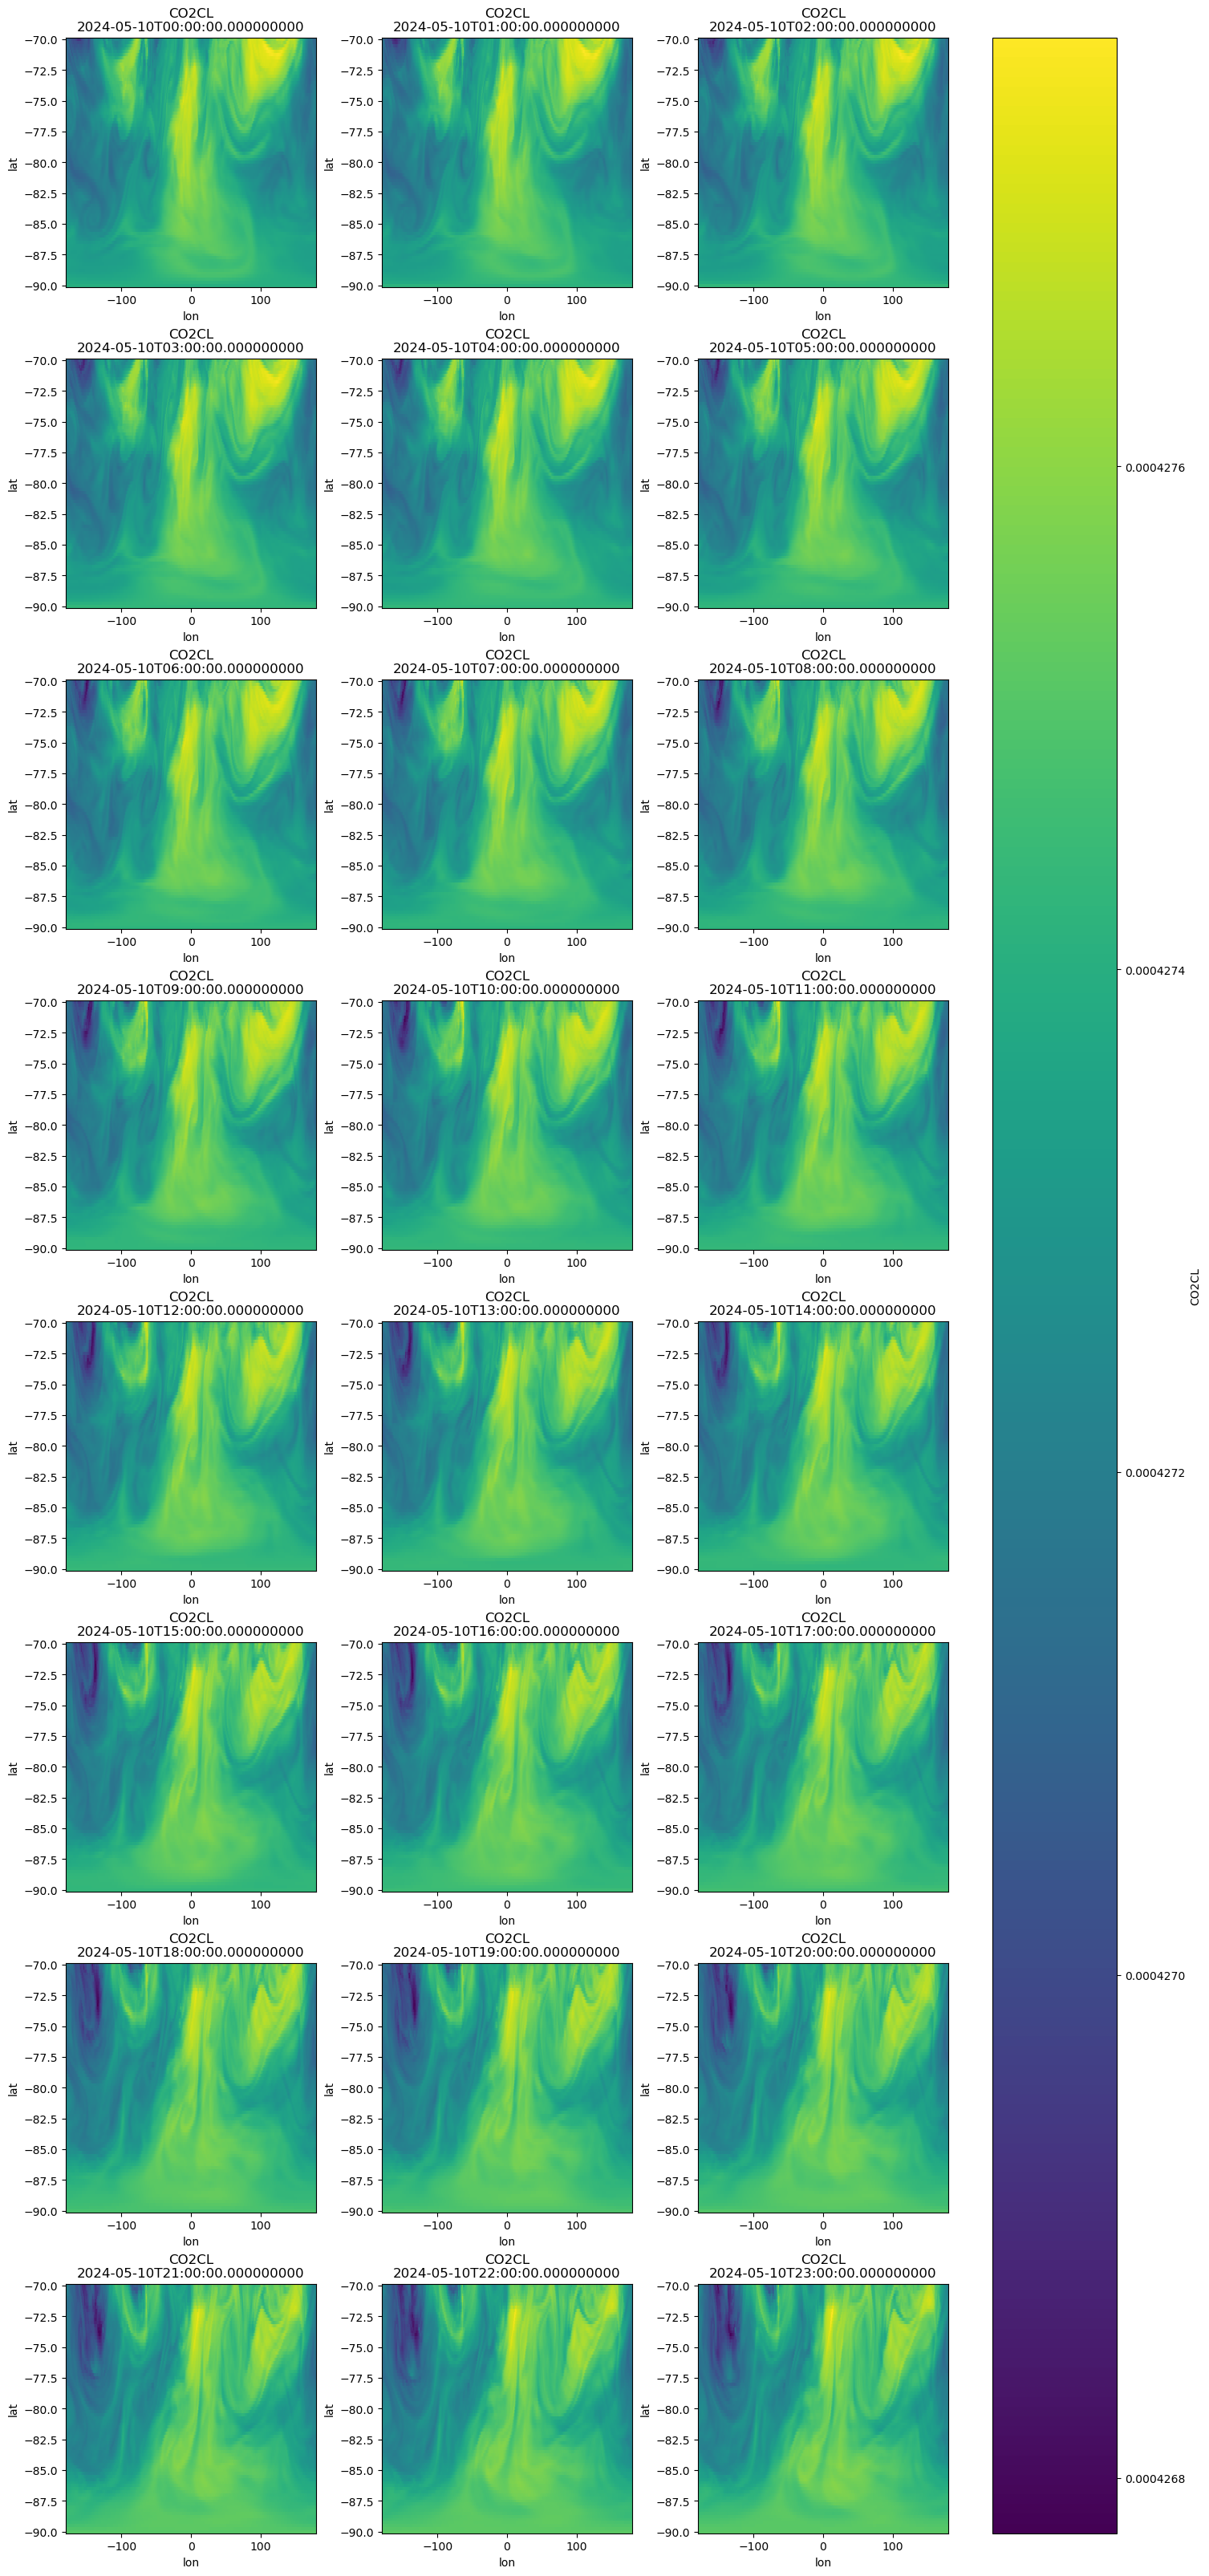

done


In [6]:
# Example:
plot_id_key_slice(
     model="GEOSFP",
     date="2024-05-10",
     id_key="inst1_2d_hwl_Nx|CO2CL|None|Strat1",
     data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
     strata_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/strata.yaml",
)
print("done")